# Entrega 1 - CoderHouse - Data Science 1
## Estudiante: Agustina Belen Yañez

# Abstract

El dataset elegido para este proyecto contiene información sobre distintos factores que pueden influir en el rendimiento académico de los estudiantes. La idea es analizar qué variables impactan más en los puntajes de examen y, a partir de eso, poder anticipar cómo se desempeñan los alumnos. Entre las variables incluidas están: horas de estudio, asistencia a clase, motivación, apoyo de los padres, acceso a recursos educativos, participación en actividades extracurriculares, situación familiar, nivel socioeconómico, distancia desde el hogar y otros aspectos que pueden marcar la diferencia en los resultados.

La pregunta que guía este análisis es: ¿Qué factores influyen más en el rendimiento académico y cómo se relacionan entre sí? Esto permite no solo identificar los determinantes más importantes del desempeño, sino también entender patrones y situaciones que se repiten o que son excepcionales dentro del grupo de estudiantes.

El objetivo del proyecto es generar un panorama claro de qué aspectos favorecen un mejor rendimiento y cuáles podrían estar limitando los resultados, considerando tanto factores individuales como contextuales. Esto ayuda a tener una visión más completa de la situación académica de los estudiantes y sienta las bases para futuros análisis o modelos predictivos que puedan anticipar el desempeño y orientar estrategias de estudio o acompañamiento educativo.

# Preguntas de interes

* ¿Qué factores influyen más en el rendimiento académico de los estudiantes (Exam_Score)?

* ¿Cómo se relacionan las horas de estudio, la asistencia y la motivación con los puntajes obtenidos?

* ¿El acceso a recursos educativos, la participación de los padres o la distancia desde el hogar afectan significativamente el desempeño?

* ¿Existen diferencias claras en el rendimiento entre estudiantes con distintos niveles de apoyo familiar, socioeconómico o escolar?

* ¿Se pueden identificar casos excepcionales que difieran del comportamiento general del grupo y qué características tienen?

# Hipotesis

* Los estudiantes con más horas de estudio y mayor asistencia obtienen puntajes más altos.

* Una mayor motivación se asocia con un mejor desempeño, incluso si otros factores son bajos.

* El acceso a recursos educativos y el apoyo parental favorecen significativamente los puntajes, especialmente en estudiantes de escuelas públicas.

* La distancia desde el hogar puede afectar la asistencia y, por ende, el rendimiento académico.

* Casos excepcionales de alto puntaje pueden deberse a combinaciones de motivación, estudio y apoyo familiar, incluso cuando otros factores son medianos o bajos.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="darkgrid")

In [94]:
DataSet = pd.read_csv("https://raw.githubusercontent.com/aby0202/Data-Science---Coder/refs/heads/main/StudentPerformanceFactors.csv")

In [95]:
DataSet.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [96]:
print("Dimensiones del DataFrame:")
DataSet.shape

Dimensiones del DataFrame:


(6607, 20)

In [97]:
DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

### Variables potencialmente interesantes

- **Hours_Studied**: cantidad de horas dedicadas al estudio. Es una de las variables más directas que podrían impactar en el puntaje final.

- **Attendance**: porcentaje de asistencia. La presencia en clase puede influir en la comprensión de los contenidos y en el compromiso general.

- **Previous_Scores**: puntajes anteriores. Permite ver si existe una continuidad en el rendimiento o si hay cambios significativos.

- **Motivation_Level**: nivel de motivación del estudiante. Puede explicar diferencias importantes en el desempeño académico.

- **Parental_Involvement**: grado de participación de los padres en la educación. Puede influir en el acompañamiento y apoyo que recibe el estudiante.

- **Family_Income**: ingreso familiar. Es relevante porque puede influir en el acceso a recursos educativos y oportunidades.

- **Access_to_Resources**: acceso a materiales educativos. Puede marcar una diferencia en el rendimiento.

- **Peer_Influence**: influencia de los pares. El entorno social puede motivar o distraer.

- **Extracurricular_Activities**: participación en actividades extracurriculares. Puede aportar habilidades adicionales o afectar el tiempo de estudio.

- **Physical_Activity**: nivel de actividad física. Puede influir en la concentración y bienestar general.

- **Sleep_Hours**: cantidad de horas de sueño. El descanso adecuado impacta en el rendimiento cognitivo.

- **Distance_from_Home**: distancia entre el hogar y la escuela. Puede afectar el cansancio y la puntualidad.

- **Learning_Disabilities**: presencia de dificultades de aprendizaje. Es importante considerarlo para entender diferencias en el desempeño.

- **Exam_Score**: puntaje final del examen. Es la variable objetivo que se busca explicar o predecir.

In [98]:
#Revisamos cantidad de datos nulos
DataSet.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [99]:
#Completo los datos nulos de la variable a usar de Distance_from_Home usando la moda. Como Parental_Education_Level y Teacher_Quality no son las principales variables a usar, no las corrijo
DataSet["Distance_from_Home"] = DataSet["Distance_from_Home"].fillna(
    DataSet["Distance_from_Home"].mode()[0]
)

#verifico
DataSet.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


## 2.Resolución de Ejercicio Visualizaciones

Para responder la pregunta problema, realizare visualizaciones
utilizando Matplotlib y Seaborn, con el objetivo de identificar relaciones
entre variables académicas, sociales y el puntaje final.

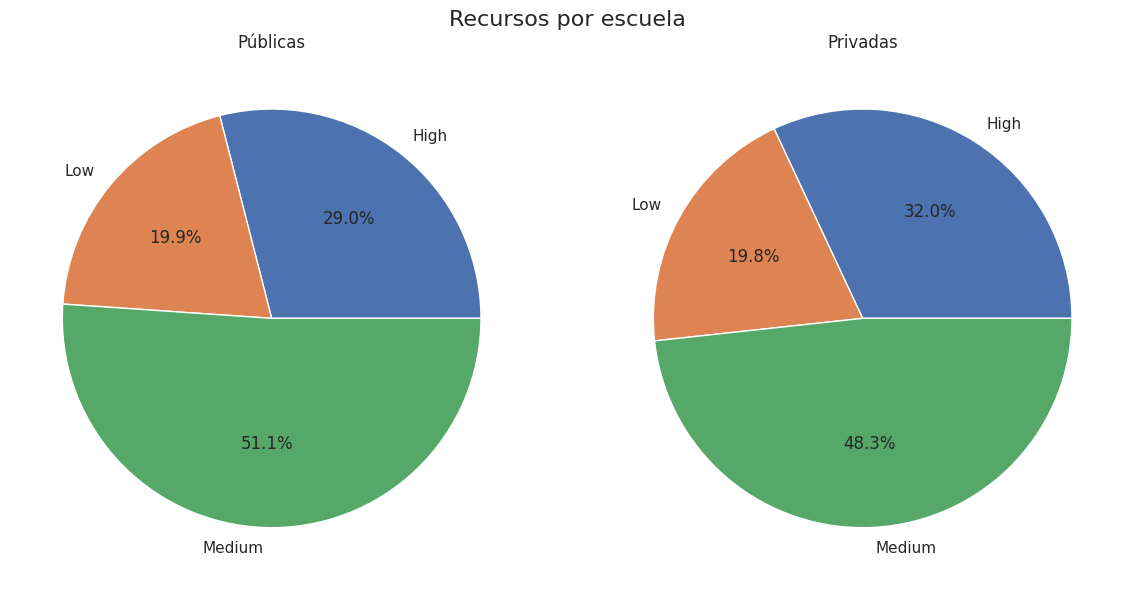

In [100]:
#Grafico con Matplotlibe, Pie chart

fig, axes = plt.subplots(1, 2, figsize=(12,6))  # 1 fila, 2 columnas

# Pie chart escuelas públicas
school_counts.loc["Public"].plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0],
    title="Públicas"
)
axes[0].set_ylabel('')  # quitamos la etiqueta del eje

# Pie chart escuelas privadas
school_counts.loc["Private"].plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1],
    title="Privadas"
)
axes[1].set_ylabel('')  # quitamos la etiqueta del eje

fig.suptitle('Recursos por escuela', fontsize=16)
plt.tight_layout()  # ajusta los gráficos para que no se superpongan

plt.show()

# Insights de Recursos por escuela privada o pública | ¿El acceso a recursos educativos afecta el desempeño?

* La mayoría de los estudiantes públicos tienen acceso medio a recursos (51.1%), mientras que solo un 29% tienen acceso alto.

* En las escuelas privadas, el porcentaje de estudiantes con acceso alto a recursos es mayor (32%) y el medio también representa un porcentaje importante (48.3%).

* Conclusión parcial: Los estudiantes de escuelas privadas tienden a tener mayor proporción de acceso a recursos educativos altos, lo que podría favorecer un mejor rendimiento académico. Esto confirma la hipótesis de que el acceso a recursos influye en el puntaje.

* Esto también muestra que, aunque el bajo acceso es similar en ambos tipos de escuela (19%), la distribución del medio y alto acceso es distinta, lo que sugiere que el tipo de escuela influye indirectamente en la disponibilidad de recursos y potencial rendimiento.

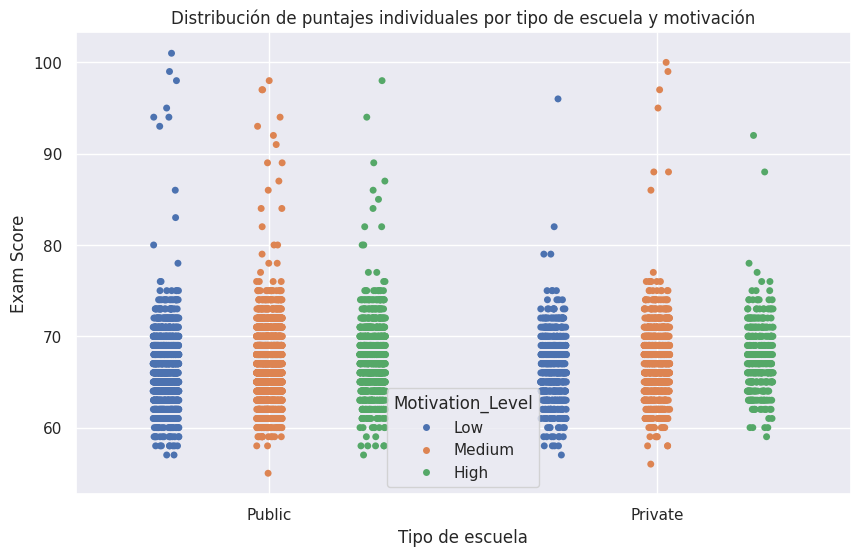

In [101]:
#Gráfico Strip Plot con Seaborn

plt.figure(figsize=(10,6))
sns.stripplot(data=DataSet, x="School_Type", y="Exam_Score", hue="Motivation_Level", jitter=True, dodge=True)
plt.title("Distribución de puntajes individuales por tipo de escuela y motivación")
plt.ylabel("Exam Score")
plt.xlabel("Tipo de escuela")
plt.grid(True)
plt.show()

# Insights de distribución de puntajes por tipo de escuela y motivación

* En ambos tipos de escuela, la gran mayoría de los estudiantes se encuentran en el rango de 60 a 75 puntos.

* Casos excepcionales:En las escuelas Públicas, hay algunos estudiantes con motivación "Baja" (azul) que lograron puntajes muy altos (cerca de 100)

* En las escuelas Privadas, los puntajes más altos (90-100) parecen estar más asociados a estudiantes con motivación "Media" (naranja)

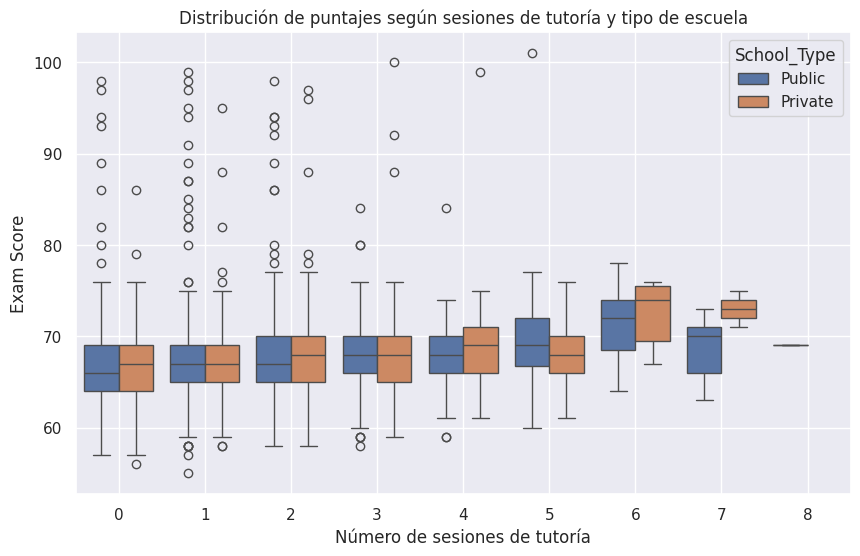

In [102]:
#Gráfico Box Plot con Seaborn

plt.figure(figsize=(10,6))
sns.boxplot(
    data=DataSet,
    x="Tutoring_Sessions",
    y="Exam_Score",
    hue="School_Type"
)
plt.title("Distribución de puntajes según sesiones de tutoría y tipo de escuela")
plt.xlabel("Número de sesiones de tutoría")
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()

# Insights de Distribución de puntajes segun sesiones de tutoria y tipo de escuela

* A medida que aumenta el número de sesiones de tutoría (de 0 a 6), la mediana del puntaje (la línea horizontal dentro de cada caja) tiende a subir ligeramente.

* Los "Outliers" (Puntos negros) por encima de las categorías de 0 a 3 sesiones significan que hay muchos estudiantes que logran puntajes de 90 o 100 sin necesidad de muchas tutorías.

* En las categorías de 6 y 7 sesiones, las escuelas privadas (naranja) muestran una mediana superior y una caja más compacta en puntajes altos que las públicas (azul).

* Las tutorías actuan como una red de seguridad: mientras más tutorías hay, menos alumnos sacan puntajes muy bajos (menos de 60)

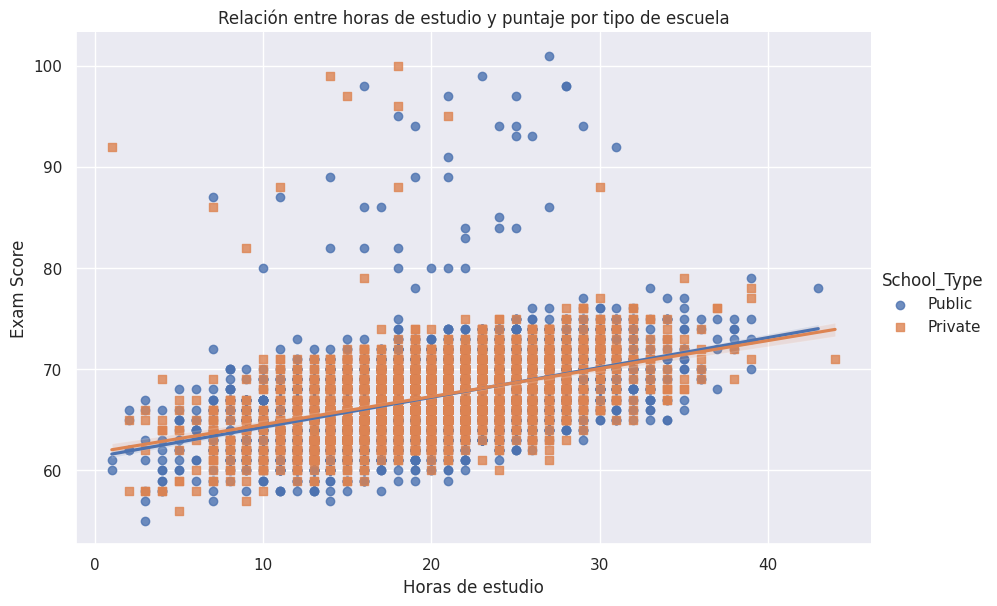

In [103]:
#Gráfico Scatter plot con regresión usando Seaborn

sns.lmplot(
    data=DataSet,
    x="Hours_Studied",
    y="Exam_Score",
    hue="School_Type",   # diferencia por tipo de escuela
    height=6,
    aspect=1.5,
    markers=["o","s"]
)
plt.title("Relación entre horas de estudio y puntaje por tipo de escuela")
plt.xlabel("Horas de estudio")
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()

# Insights de la relación entre horas de estudio y puntaje por escuela | ¿Qué factores influyen más en el rendimiento académico?
* Ambas líneas (azul y naranja) tienen una pendiente ascendente. Esto demuestra que a más horas de estudio, mayor es el puntaje del examen de forma generalizada.

* Las dos líneas de regresión están prácticamente superpuestas. Esto significa que una hora extra de estudio rinde lo mismo independientemente de si el alumno va a una escuela pública o privada. La tendencia se mantiene en ambos tipos de escuela, confirmando la hipótesis de que más estudio se traduce en mejor rendimiento.

* Se nota una mayor densidad de puntos de escuelas públicas en la zona de puntajes muy altos (90-100) con menos de 30 horas de estudio, comparado con las privadas

* La mayoría de los estudiantes se concentran entre las 10 y 35 horas de estudio, con puntajes entre 60 y 75.

* Entre los casos atípicos, vemos puntos muy arriba de la línea de tendencia. Hay alumnos que con solo 15 horas de estudio sacaron casi 100 puntos, mientras que otros con 40 horas apenas superaron los 70. Esto refuerza que el tiempo no es el único factor del éxito.

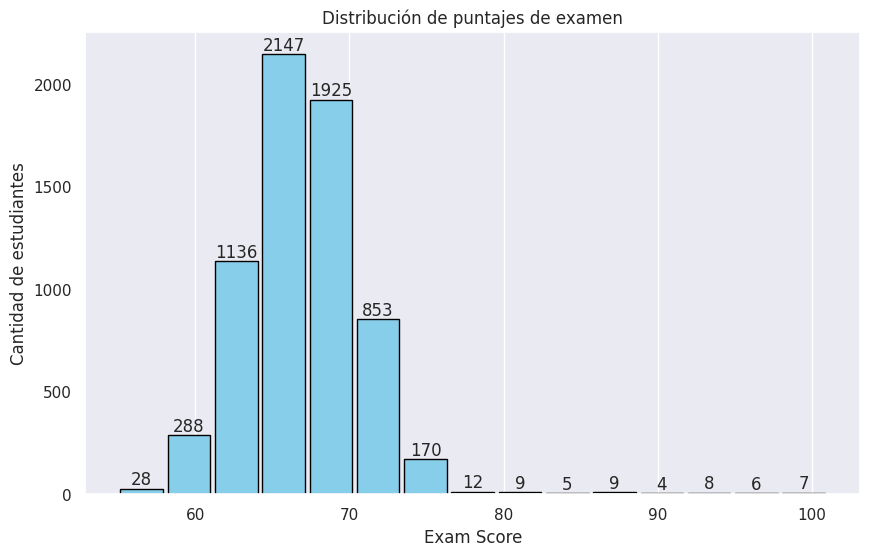

In [104]:
#Gráfico histograma de Matplotlib

plt.figure(figsize=(10,6))
counts, bins_edges, patches = plt.hist(
    DataSet["Exam_Score"],
    bins=15,
    color="skyblue",
    edgecolor="black",
    rwidth=0.9  # <--- hace que la barra ocupe 90% del espacio, deja 10% de separación
)
plt.title("Distribución de puntajes de examen")
plt.xlabel("Exam Score")
plt.ylabel("Cantidad de estudiantes")
plt.grid(axis='y')

# Números encima de cada barra
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            int(count),
            ha='center', va='bottom'
        )

plt.show()

# Insights de distribución de puntajes segun cantidad de estudiantes | ¿Se pueden identificar casos excepcionales?

* El rendimiento académico está altamente centralizado; más de 4,000 estudiantes (la gran mayoría) obtienen puntajes entre 65 y 75, con un pico máximo de 2,147 alumnos en el rango de 65-70.

* La distribución presenta un sesgo marcado hacia la derecha. Es común alcanzar notas medias, pero la cantidad de alumnos disminuye drásticamente al acercarse a la excelencia (notas > 85), donde los grupos se reducen a menos de 10 personas por rango.

* Los puntajes perfectos de 100 puntos son reales pero estadísticamente insignificantes en volumen (solo 7 casos), lo que confirma que son excepciones al comportamiento general del alumnado.

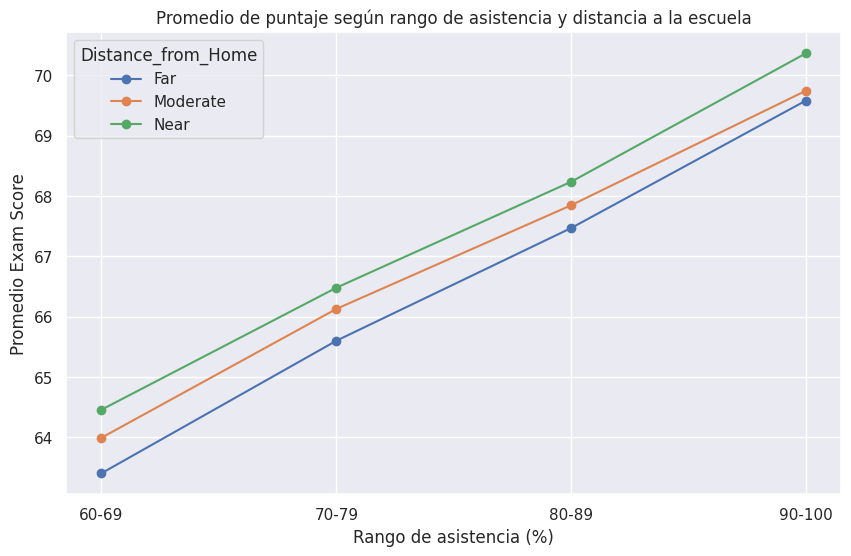

In [105]:
#Gráfico de líneas usando Matplotlib

# Crear la columna 'Attendance_Range' a partir de 'Attendance'
bins = [50, 60, 70, 80, 90, 100]
labels = ['50-59', '60-69', '70-79', '80-89', '90-100']
DataSet['Attendance_Range'] = pd.cut(DataSet['Attendance'], bins=bins, labels=labels, right=False, include_lowest=True)

# Calcular promedio de Exam_Score por rango de asistencia y distancia
avg_scores = DataSet.groupby(
    ["Attendance_Range","Distance_from_Home"],
    observed=True   # <--- evita el FutureWarning
)["Exam_Score"].mean().unstack()

plt.figure(figsize=(10,6))
for dist in avg_scores.columns:
    plt.plot(avg_scores.index, avg_scores[dist], marker='o', label=dist)

plt.title("Promedio de puntaje según rango de asistencia y distancia a la escuela")
plt.xlabel("Rango de asistencia (%)")
plt.ylabel("Promedio Exam Score")
plt.grid(True)
plt.legend(title="Distance_from_Home")
plt.show()

# Insights de puntaje, distancia a la escuela y asistencia | ¿La asistencia y la distancia afectan el rendimiento?

* Los alumnos que asisten más a clases (rango 90-100%) obtienen puntajes mucho más altos (alrededor de 70) que aquellos que asisten poco (rango 50-59%, que tienen puntajes cercanos a 60-63).

* Los alumnos que viven cerca tienen, en promedio, mejores notas que el resto, sin importar su nivel de asistencia.
Los alumnos que viven lejos obtienen, en promedio, los puntajes más bajos dentro de cada rango de asistencia. Esto respalda la hipótesis de que la asistencia y la proximidad a la escuela influyen positivamente en el desempeño.

* Aunque vivir lejos parece ser una desventaja, la asistencia alta actúa como un "igualador". Si un alumno que vive lejos asiste casi siempre (90-100%), su nota promedio sube drásticamente, acercándose mucho a la de los que viven cerca.
